<a href="https://colab.research.google.com/github/Christianib003/rekomai/blob/clint/notebooks/image_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Data Collection and Processing

In [1]:
# 1. Setup & Imports
!pip install deepface albumentations opencv-python --quiet

import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from deepface import DeepFace
import albumentations as A
from albumentations import HorizontalFlip, Rotate, ToGray


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.9 MB/s eta 0:00:00
25-07-26 11:29:33 - Directory /root/.deepface has been created
25-07-26 11:29:33 - Directory /root/.deepface/weights has been created


In [2]:
# Clone the GitHub repo with images
!git clone https://github.com/Christianib003/rekomai.git

Cloning into 'rekomai'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 119 (delta 51), reused 54 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 2.36 MiB | 15.58 MiB/s, done.
Resolving deltas: 100% (51/51), done.


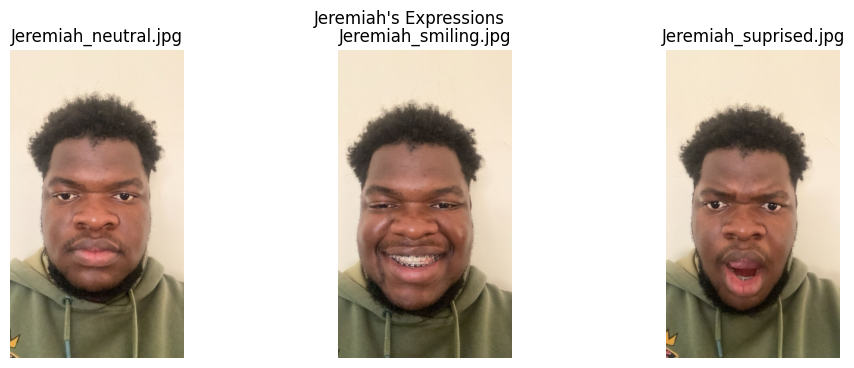

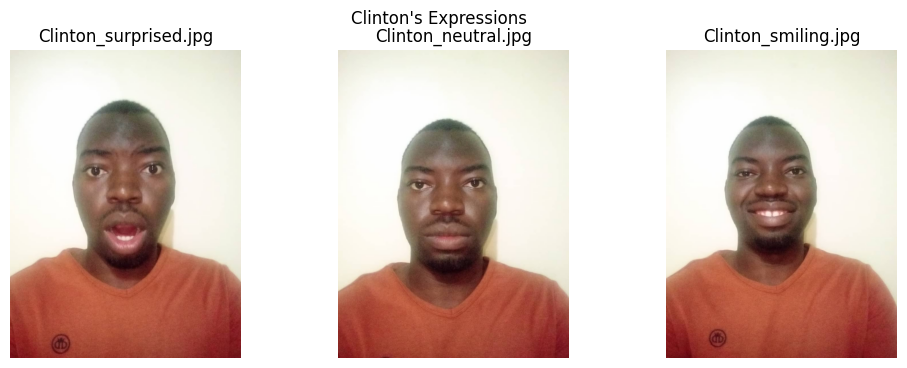

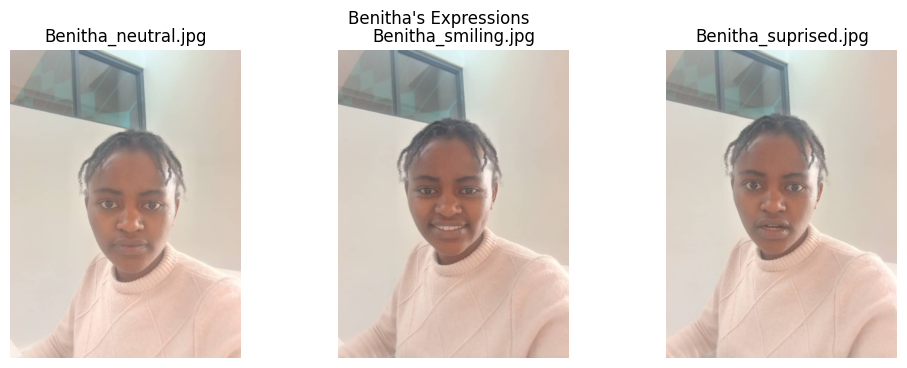

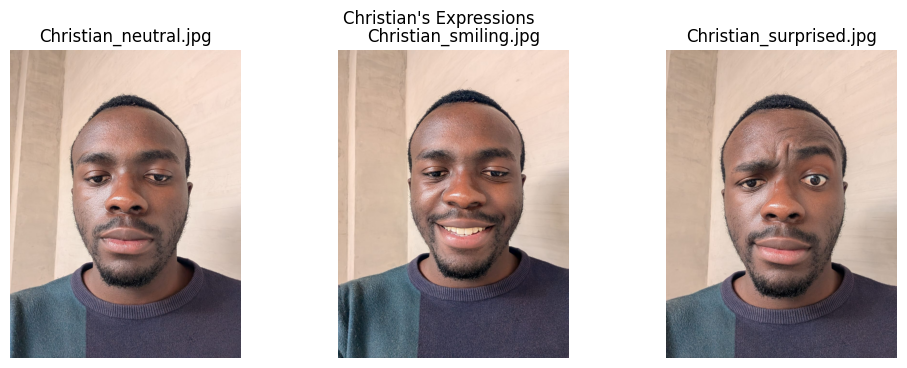

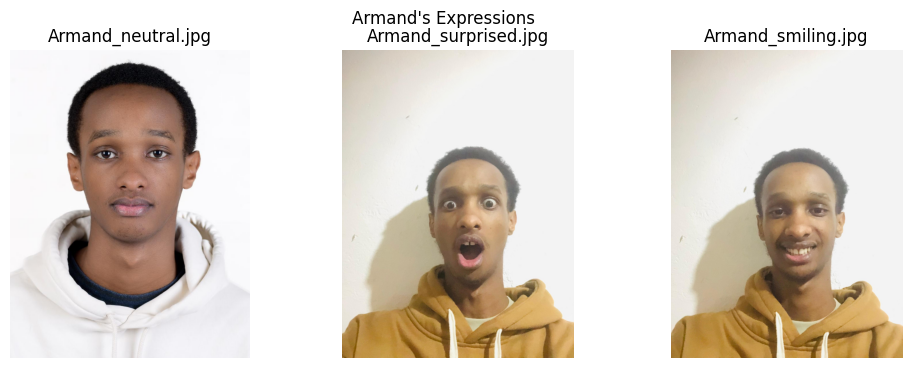

In [3]:
# 2. Display Original Images
def load_and_display_images(base_path='rekomai/data/images/'):
    members = os.listdir(base_path)
    for member in members:
        folder = os.path.join(base_path, member)
        if os.path.isdir(folder): # Add this check to ensure it's a directory
            images = [os.path.join(folder, img) for img in os.listdir(folder) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

            plt.figure(figsize=(12, 4))
            for idx, img_path in enumerate(images):
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                plt.subplot(1, len(images), idx+1)
                plt.imshow(img)
                plt.title(os.path.basename(img_path))
                plt.axis('off')
            plt.suptitle(f"{member}'s Expressions")
            plt.show()

load_and_display_images()

In [4]:
# 3. Define Augmentation Pipeline using Albumentations
augment = A.Compose([
    HorizontalFlip(p=1.0),    # Flip horizontally
    Rotate(limit=20, p=1.0),  # Rotate within ±20 degrees
    ToGray(p=1.0),            # Convert to grayscale
])

def apply_augmentations(image):
    augmented = augment(image=image)
    return augmented['image']

In [5]:
# 4. Extract Face Embeddings using DeepFace
def extract_embedding(img_path):
    try:
        embedding = DeepFace.represent(img_path=img_path, model_name='Facenet')[0]['embedding']
        return embedding
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return [None] * 128  # fallback placeholder

In [6]:
# 5. Process and Save Features
data = []

def process_member_images(base_path='rekomai/data/images/'):
    for member in os.listdir(base_path):
        folder = os.path.join(base_path, member)
        if os.path.isdir(folder): # Add this check to ensure it's a directory
            for img_file in os.listdir(folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(folder, img_file)

                    # Optional: Apply augmentation to each image before feature extraction
                    # image = cv2.imread(img_path)
                    # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                    # image = apply_augmentations(image)

                    embedding = extract_embedding(img_path)
                    data.append({
                        'user_id': member,
                        'expression': img_file.split('.')[0],
                        'image_path': img_path,
                        **{f'feat_{i}': val for i, val in enumerate(embedding)}
                    })

process_member_images()

Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5


25-07-26 11:30:33 - facenet_weights.h5 will be downloaded...


100%|██████████| 92.2M/92.2M [00:00<00:00, 210MB/s]


Error processing rekomai/data/images/Clinton/Clinton_surprised.jpg: Face could not be detected in rekomai/data/images/Clinton/Clinton_surprised.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.


In [7]:
# Convert to DataFrame and Save
image_features_df = pd.DataFrame(data)

In [8]:
# Ensure directory exists
os.makedirs("data/customer-info", exist_ok=True)
image_features_df.to_csv("data/customer-info/image_features.csv", index=False)

In [9]:
# 6. Preview Feature Dataset
image_features_df.head()

image_features_df.tail()

,user_id,expression,image_path,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,...,feat_118,feat_119,feat_120,feat_121,feat_122,feat_123,feat_124,feat_125,feat_126,feat_127
10,Christian,Christian_smiling,rekomai/data/images/Christian/Christian_smilin...,0.096169,-0.794796,0.496273,1.449671,1.404864,-1.728458,0.816244,...,-1.874019,0.003964,0.067256,-1.848896,2.345852,-1.416912,0.529485,0.206451,1.152706,-0.265067
11,Christian,Christian_surprised,rekomai/data/images/Christian/Christian_surpri...,-0.724054,-0.607936,-0.328607,-0.370530,0.357090,-0.074485,-0.234159,...,1.077550,0.173884,-0.372883,-0.629632,0.236764,0.092748,0.501842,-0.385920,1.095517,0.439314
12,Armand,Armand_neutral,rekomai/data/images/Armand/Armand_neutral.jpg,-0.138471,-1.151697,-1.239582,0.148049,-0.177345,1.843763,-0.410440,...,1.519359,-0.568646,-0.940807,0.946104,0.643062,-0.982694,-0.670675,-0.584985,0.104936,-0.657133
13,Armand,Armand_surprised,rekomai/data/images/Armand/Armand_surprised.jpg,-0.479697,-1.373364,-0.616432,0.279288,0.701400,1.487678,0.645229,...,0.562135,0.102581,-0.290011,0.720749,2.145457,-0.361465,0.001556,-1.016598,0.823680,0.161360
14,Armand,Armand_smiling,rekomai/data/images/Armand/Armand_smiling.jpg,0.320235,-0.601833,-1.151199,0.306680,0.281166,2.437808,0.586774,...,0.435807,0.196972,-0.648786,0.306595,2.384832,-0.729362,-0.281726,-0.451433,1.450374,0.363208
